# Cardiovascular Disease Prediction - Machine Learning Project

This notebook presents a comprehensive machine learning project for predicting cardiovascular disease (CVD) using clinical, physical, and lifestyle features. The project includes data preprocessing, model training, evaluation, and explainability analysis using SHAP.

**Objective:** Build and compare multiple machine learning models to predict whether a patient has cardiovascular disease, with emphasis on interpretability and model explainability.

**Dataset:** Cardiovascular Disease dataset from Kaggle with 70,000 patient records and 12 features.

## Section 1: Setup and Imports

First, we'll import all necessary libraries and configure the environment for our analysis.

In [17]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost tensorflow shap imbalanced-learn scipy joblib

import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
import xgboost as xgb
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Explainability
import shap

# Feature Selection
from sklearn.feature_selection import SelectKBest, chi2
from imblearn.over_sampling import SMOTE

# Utilities
import joblib
import sys
sys.path.append('.')

# Import custom modules
from preprocessing import prepare_data_pipeline
from train import train_models, cross_validate_models
from evaluate import evaluate_all_models, plot_all_confusion_matrices, plot_all_roc_curves_combined, plot_model_comparison
from explain import explain_with_shap, plot_shap_summary, plot_shap_bar, plot_shap_waterfall, get_top_features
from feature_selection import plot_feature_importance_comparison, get_consensus_top_features, selectkbest_features
from utils import save_model, load_model, save_plot, print_dataset_summary, get_best_model, create_project_summary, save_results

print("✓ All imports successful!")

Note: you may need to restart the kernel to use updated packages.
✓ All imports successful!


## Section 2: Load and Explore Data

We'll load the cardiovascular disease dataset and perform initial exploration to understand the data structure, missing values, and class distribution.

In [6]:
# Load dataset
dataset_path = 'data/cardio_train.csv'

try:
    df = pd.read_csv(dataset_path, sep=';')
    if df.shape[1] == 1:
        df = pd.read_csv(dataset_path, sep=',')
    print(f"✓ Dataset loaded successfully")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print(f"✗ Error: Dataset not found at {dataset_path}")
    print("Please place 'cardio_train.csv' in the 'data/' folder")
    raise

# Display basic info
print("\n" + "="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"\nShape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

✓ Dataset loaded successfully
Shape: (70000, 13)

DATASET OVERVIEW

Shape: (70000, 13)

First few rows:
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  

Data types:
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco            

In [7]:
# Dataset statistics
print("\n" + "="*70)
print("DATASET STATISTICS")
print("="*70)

print(f"\nTotal samples: {len(df)}")
print(f"Total features: {df.shape[1] - 1}")
print(f"\nTarget variable distribution:")

target_counts = df['cardio'].value_counts()
target_pct = df['cardio'].value_counts(normalize=True) * 100

print(f"  Class 0 (No Disease): {target_counts[0]:,} samples ({target_pct[0]:.1f}%)")
print(f"  Class 1 (Disease): {target_counts[1]:,} samples ({target_pct[1]:.1f}%)")
print(f"  Class Imbalance Ratio: {target_counts[1]/target_counts[0]:.2f}")

# Basic statistics
print(f"\nNumeric features summary:")
print(df.describe())


DATASET STATISTICS

Total samples: 70000
Total features: 12

Target variable distribution:
  Class 0 (No Disease): 35,021 samples (50.0%)
  Class 1 (Disease): 34,979 samples (50.0%)
  Class Imbalance Ratio: 1.00

Numeric features summary:
                 id           age        gender        height        weight  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean   49972.419900  19468.865814      1.349571    164.359229     74.205690   
std    28851.302323   2467.251667      0.476838      8.210126     14.395757   
min        0.000000  10798.000000      1.000000     55.000000     10.000000   
25%    25006.750000  17664.000000      1.000000    159.000000     65.000000   
50%    50001.500000  19703.000000      1.000000    165.000000     72.000000   
75%    74889.250000  21327.000000      2.000000    170.000000     82.000000   
max    99999.000000  23713.000000      2.000000    250.000000    200.000000   

              ap_hi         ap_lo   cholesterol 

## Section 3: Exploratory Data Analysis (EDA)

Visualize feature distributions, correlations, and relationships with the target variable.

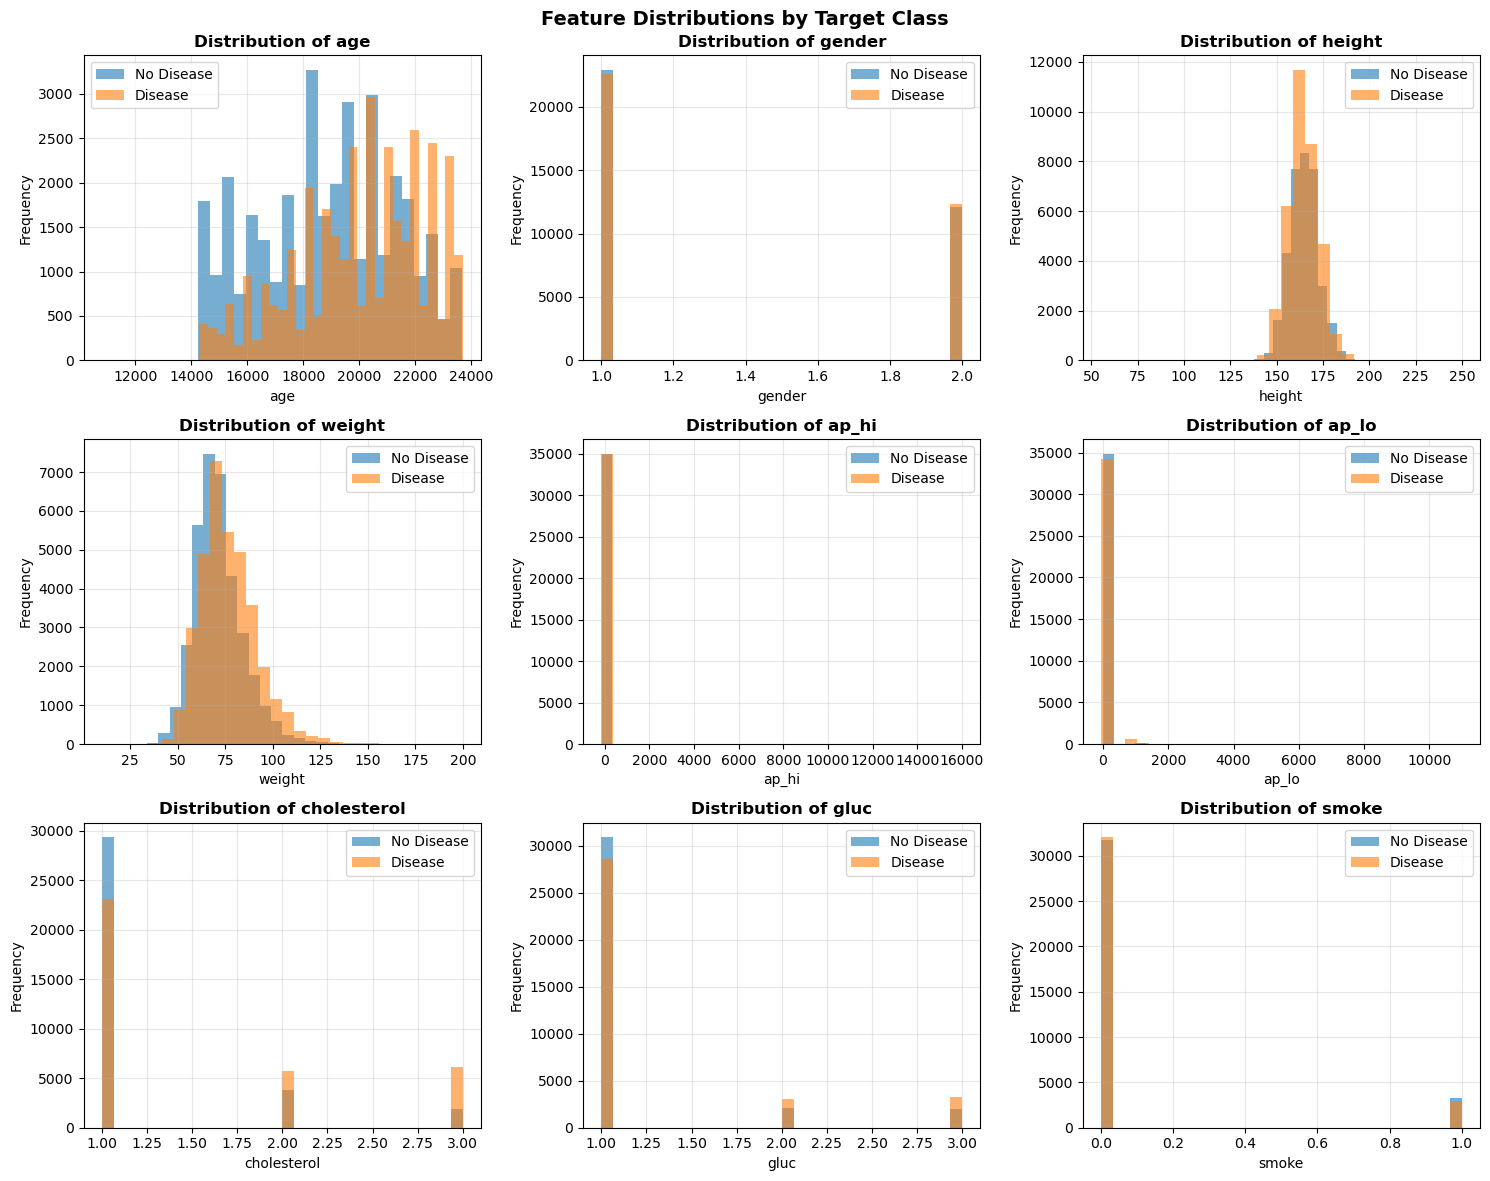

✓ Feature distributions displayed


In [8]:
# Feature distributions by target class
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Feature Distributions by Target Class', fontsize=14, fontweight='bold')
axes = axes.flatten()

numeric_cols = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 
                'cholesterol', 'gluc', 'smoke']

for idx, col in enumerate(numeric_cols):
    for target in [0, 1]:
        data = df[df['cardio'] == target][col]
        label = "Disease" if target == 1 else "No Disease"
        axes[idx].hist(data, alpha=0.6, label=label, bins=30)
    
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Feature distributions displayed")

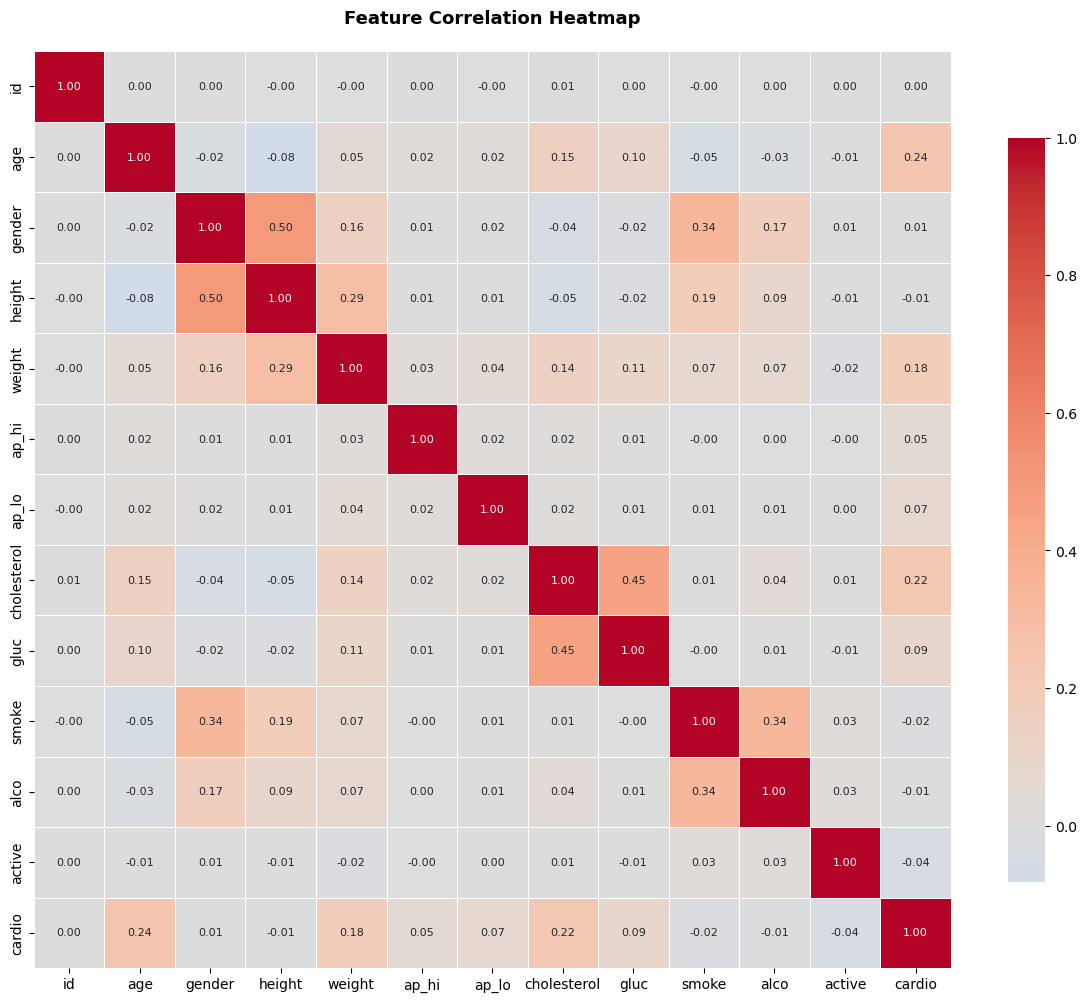

✓ Correlation heatmap displayed


In [9]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))

numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            ax=ax, annot_kws={'size': 8})

ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ Correlation heatmap displayed")

## Section 4: Data Preprocessing

Clean the data, create engineered features, handle missing values and outliers, scale features, and balance classes using SMOTE.

In [10]:
# Make a copy for preprocessing
df_clean = df.copy()

print("="*70)
print("DATA CLEANING AND PREPROCESSING")
print("="*70)

initial_rows = len(df_clean)

# Handle missing values
missing = df_clean.isnull().sum()
if missing.sum() > 0:
    print(f"\n✓ Missing values found:")
    print(missing[missing > 0])
    imputer = SimpleImputer(strategy='mean')
    numeric_cols_all = df_clean.select_dtypes(include=[np.number]).columns
    df_clean[numeric_cols_all] = imputer.fit_transform(df_clean[numeric_cols_all])
    print("✓ Missing values imputed using mean strategy")
else:
    print("\n✓ No missing values found")

# Remove duplicates
duplicates_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
duplicates_removed = duplicates_before - len(df_clean)
if duplicates_removed > 0:
    print(f"✓ Removed {duplicates_removed} duplicate rows")

# Remove outliers using IQR method
for col in ['ap_hi', 'ap_lo']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_before = len(df_clean)
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    outliers_removed = outliers_before - len(df_clean)
    if outliers_removed > 0:
        print(f"✓ Removed {outliers_removed} outliers in '{col}' (IQR method)")

total_removed = initial_rows - len(df_clean)
print(f"\n✓ Total rows removed: {total_removed}")
print(f"✓ Remaining rows: {len(df_clean)}")

DATA CLEANING AND PREPROCESSING

✓ No missing values found
✓ Removed 1435 outliers in 'ap_hi' (IQR method)
✓ Removed 4063 outliers in 'ap_lo' (IQR method)

✓ Total rows removed: 5498
✓ Remaining rows: 64502


In [11]:
# Feature Engineering
print("\n" + "="*70)
print("FEATURE ENGINEERING")
print("="*70)

df_features = df_clean.copy()

# Age from days to years
df_features['age'] = df_features['age'] / 365.25
print("✓ Age converted from days to years")

# BMI
df_features['bmi'] = df_features['weight'] / ((df_features['height'] / 100) ** 2)
print("✓ BMI calculated")

# Pulse Pressure
df_features['pulse_pressure'] = df_features['ap_hi'] - df_features['ap_lo']
print("✓ Pulse pressure calculated")

# Mean Arterial Pressure
df_features['mean_arterial_pressure'] = (df_features['ap_hi'] + 2 * df_features['ap_lo']) / 3
print("✓ Mean arterial pressure calculated")

# Lifestyle Risk Score
df_features['lifestyle_risk_score'] = df_features['smoke'] + df_features['alco'] + (1 - df_features['active'])
print("✓ Lifestyle risk score calculated")

# Health Risk Score
df_features['health_risk_score'] = df_features['cholesterol'] + df_features['gluc']
print("✓ Health risk score calculated")

# Age-BMI Interaction
df_features['age_bmi_interaction'] = df_features['age'] * df_features['bmi']
print("✓ Age-BMI interaction created")

# Blood Pressure Category
def categorize_bp(row):
    if row['ap_hi'] < 120 and row['ap_lo'] < 80:
        return 0  # Normal
    elif row['ap_hi'] >= 120 and row['ap_hi'] <= 129 and row['ap_lo'] < 80:
        return 1  # Elevated
    elif (row['ap_hi'] >= 130 and row['ap_hi'] <= 139) or (row['ap_lo'] >= 80 and row['ap_lo'] <= 89):
        return 2  # High Stage 1
    else:
        return 3  # High Stage 2

df_features['bp_category'] = df_features.apply(categorize_bp, axis=1)
print("✓ Blood pressure category created")

print(f"\n✓ Total engineered features: 8 new features added")


FEATURE ENGINEERING
✓ Age converted from days to years
✓ BMI calculated
✓ Pulse pressure calculated
✓ Mean arterial pressure calculated
✓ Lifestyle risk score calculated
✓ Health risk score calculated
✓ Age-BMI interaction created
✓ Blood pressure category created

✓ Total engineered features: 8 new features added


In [12]:
# Prepare X and y
target_col = 'cardio'
X = df_features.drop(columns=[target_col])
y = df_features[target_col]

# Ensure only numeric columns
X = X.select_dtypes(include=[np.number])
feature_names = X.columns.tolist()

print(f"\nFeatures: {len(feature_names)}")
print(f"Training samples: {len(X)}")
print(f"\nFeature list:")
for i, feat in enumerate(feature_names, 1):
    print(f"  {i:2d}. {feat}")


Features: 19
Training samples: 64502

Feature list:
   1. id
   2. age
   3. gender
   4. height
   5. weight
   6. ap_hi
   7. ap_lo
   8. cholesterol
   9. gluc
  10. smoke
  11. alco
  12. active
  13. bmi
  14. pulse_pressure
  15. mean_arterial_pressure
  16. lifestyle_risk_score
  17. health_risk_score
  18. age_bmi_interaction
  19. bp_category


In [13]:
# Split data
print("\n" + "="*70)
print("TRAIN-TEST SPLIT")
print("="*70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✓ Stratified split completed")
print(f"  Training set: {X_train.shape}")
print(f"  Test set: {X_test.shape}")

# Scale features
print("\n" + "="*70)
print("FEATURE SCALING")
print("="*70)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✓ Features scaled using StandardScaler")
print(f"  Scaler fit on training data ({X_train_scaled.shape[0]} samples)")
print(f"  Transformation applied to test data ({X_test_scaled.shape[0]} samples)")


TRAIN-TEST SPLIT

✓ Stratified split completed
  Training set: (51601, 19)
  Test set: (12901, 19)

FEATURE SCALING

✓ Features scaled using StandardScaler
  Scaler fit on training data (51601 samples)
  Transformation applied to test data (12901 samples)


In [14]:
# Handle class imbalance with SMOTE
print("\n" + "="*70)
print("HANDLING CLASS IMBALANCE WITH SMOTE")
print("="*70)

print("\nBefore SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    label = "Disease" if u == 1 else "No Disease"
    print(f"  Class {u} ({label}): {c:,} samples ({100*c/len(y_train):.1f}%)")

# Apply SMOTE
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE:")
unique, counts = np.unique(y_train_balanced, return_counts=True)
for u, c in zip(unique, counts):
    label = "Disease" if u == 1 else "No Disease"
    print(f"  Class {u} ({label}): {c:,} samples ({100*c/len(y_train_balanced):.1f}%)")

print("\n✓ Data preprocessing complete")


HANDLING CLASS IMBALANCE WITH SMOTE

Before SMOTE:
  Class 0 (No Disease): 25,884 samples (50.2%)
  Class 1 (Disease): 25,717 samples (49.8%)

After SMOTE:
  Class 0 (No Disease): 25,884 samples (50.0%)
  Class 1 (Disease): 25,884 samples (50.0%)

✓ Data preprocessing complete


## Section 5: Model Training

Train 6 different machine learning models:
1. Logistic Regression
2. Random Forest
3. XGBoost
4. Support Vector Machine (SVM)
5. Neural Network
6. Stacking Ensemble

In [15]:
# Split training data for neural network validation
X_train_nn, X_val, y_train_nn, y_val = train_test_split(
    X_train_balanced, y_train_balanced,
    test_size=0.2,
    random_state=42
)

print("="*70)
print("TRAINING ALL MODELS")
print("="*70 + "\n")

models = {}
histories = {}

# 1. Logistic Regression
print("1. Training Logistic Regression...", end=" ")
models['Logistic Regression'] = LogisticRegression(
    C=1, max_iter=500, random_state=42, n_jobs=-1
)
models['Logistic Regression'].fit(X_train_balanced, y_train_balanced)
print("✓")

# 2. Random Forest
print("2. Training Random Forest...", end=" ")
models['Random Forest'] = RandomForestClassifier(
    n_estimators=200, max_depth=20, random_state=42, n_jobs=-1
)
models['Random Forest'].fit(X_train_balanced, y_train_balanced)
print("✓")

# 3. XGBoost
print("3. Training XGBoost...", end=" ")
models['XGBoost'] = xgb.XGBClassifier(
    max_depth=10, learning_rate=0.1, n_estimators=200,
    objective='binary:logistic', random_state=42, n_jobs=-1,
    use_label_encoder=False, eval_metric='logloss'
)
models['XGBoost'].fit(X_train_balanced, y_train_balanced)
print("✓")

# 4. SVM
print("4. Training SVM...", end=" ")
models['SVM'] = SVC(C=10, kernel='rbf', probability=True, random_state=42)
models['SVM'].fit(X_train_balanced, y_train_balanced)
print("✓")

print("\n✓ All non-neural network models trained successfully")

TRAINING ALL MODELS

1. Training Logistic Regression... ✓
2. Training Random Forest... ✓
3. Training XGBoost... ✓
4. Training SVM... ✓

✓ All non-neural network models trained successfully


In [18]:
# 5. Neural Network
print("\n5. Training Neural Network...", end=" ")

n_features = X_train_nn.shape[1]

nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = nn_model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=0
)

models['Neural Network'] = nn_model
histories['Neural Network'] = history
print("✓")


5. Training Neural Network... ✓


In [19]:
# 6. Stacking Ensemble
print("\n6. Training Stacking Ensemble...", end=" ")

base_models = [
    ('lr', models['Logistic Regression']),
    ('rf', models['Random Forest']),
    ('xgb', models['XGBoost']),
    ('svm', models['SVM'])
]

meta_learner = LogisticRegression(max_iter=500, random_state=42)

models['Stacking Ensemble'] = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5
)

models['Stacking Ensemble'].fit(X_train_balanced, y_train_balanced)
print("✓")

print("\n✓ All models trained successfully!")


6. Training Stacking Ensemble... ✓

✓ All models trained successfully!


## Section 6: Model Evaluation

Evaluate all models on the test set and compare their performance using multiple metrics.

In [20]:
# Evaluate all models
print("="*70)
print("MODEL EVALUATION ON TEST SET")
print("="*70 + "\n")

results = []
predictions = {}

for model_name, model in models.items():
    # Get predictions
    if model_name == 'Neural Network':
        y_pred_proba = model.predict(X_test_scaled, verbose=0).flatten()
        y_pred = (y_pred_proba > 0.5).astype(int)
    else:
        y_pred = model.predict(X_test_scaled)
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        else:
            y_pred_proba = model.decision_function(X_test_scaled)
    
    # Calculate metrics
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }
    
    results.append(metrics)
    predictions[model_name] = y_pred

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print()

MODEL EVALUATION ON TEST SET

              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.725913   0.754485 0.667185  0.708155 0.791811
      Random Forest  0.729478   0.747059 0.691291  0.718094 0.792551
            XGBoost  0.721029   0.737381 0.683826  0.709594 0.785550
                SVM  0.729401   0.760042 0.667963  0.711034 0.777240
     Neural Network  0.731339   0.748241 0.694712  0.720484 0.800128
  Stacking Ensemble  0.731649   0.750422 0.691602  0.719812 0.798078



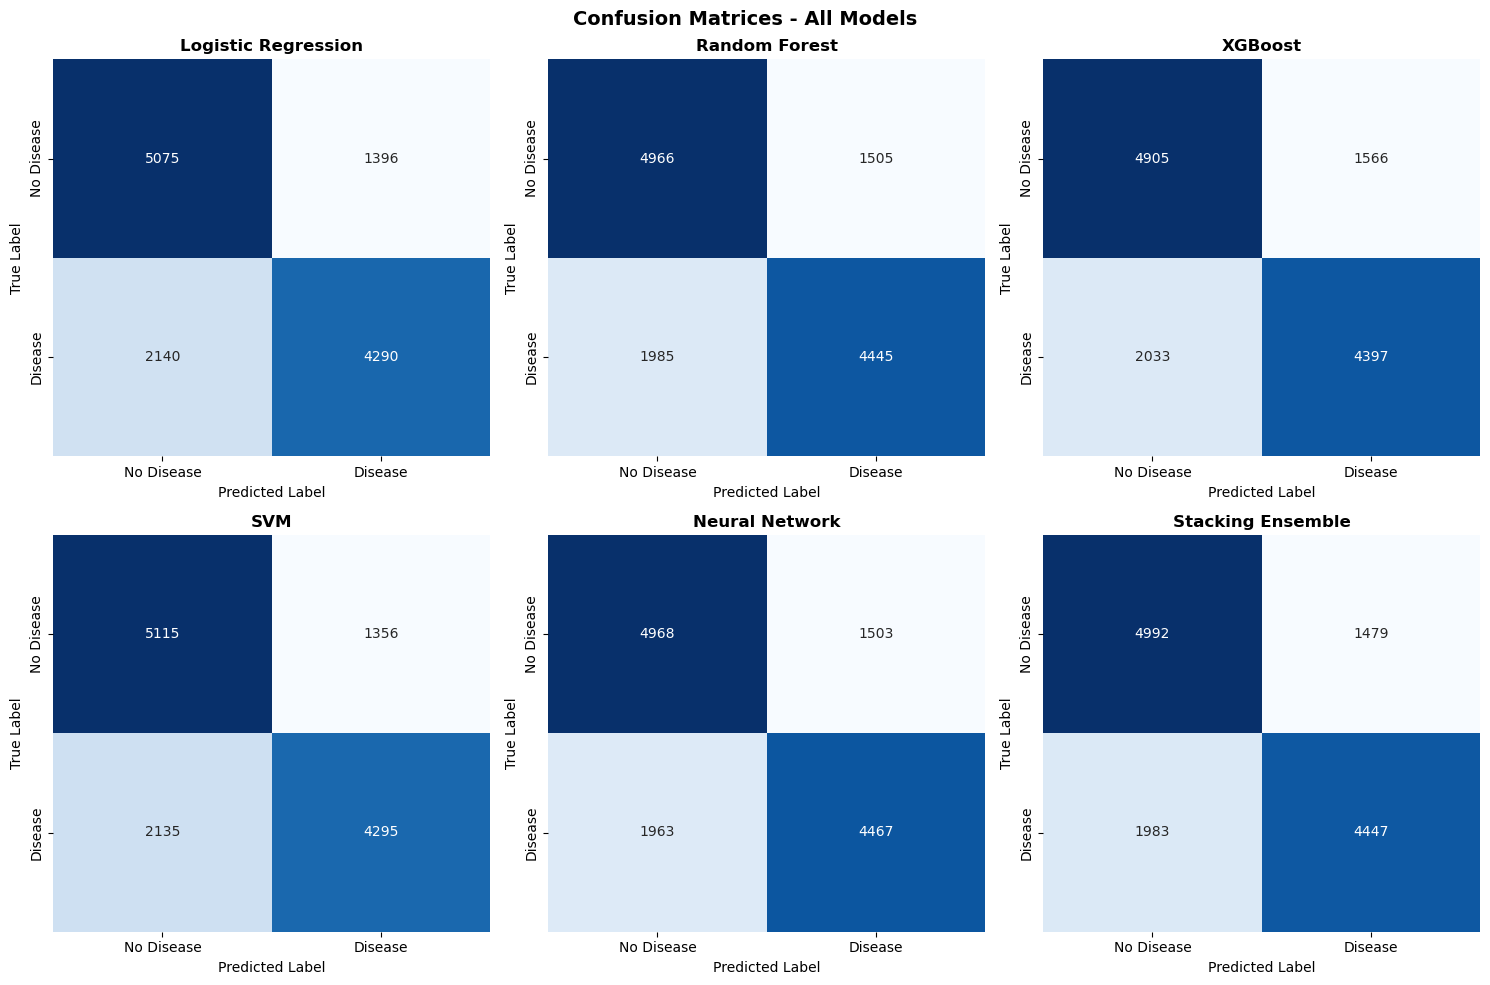

✓ Confusion matrices displayed


In [21]:
# Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold')
axes = axes.flatten()

models_list = list(models.keys())

for idx, model_name in enumerate(models_list):
    cm = confusion_matrix(y_test, predictions[model_name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    axes[idx].set_title(f'{model_name}', fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("✓ Confusion matrices displayed")

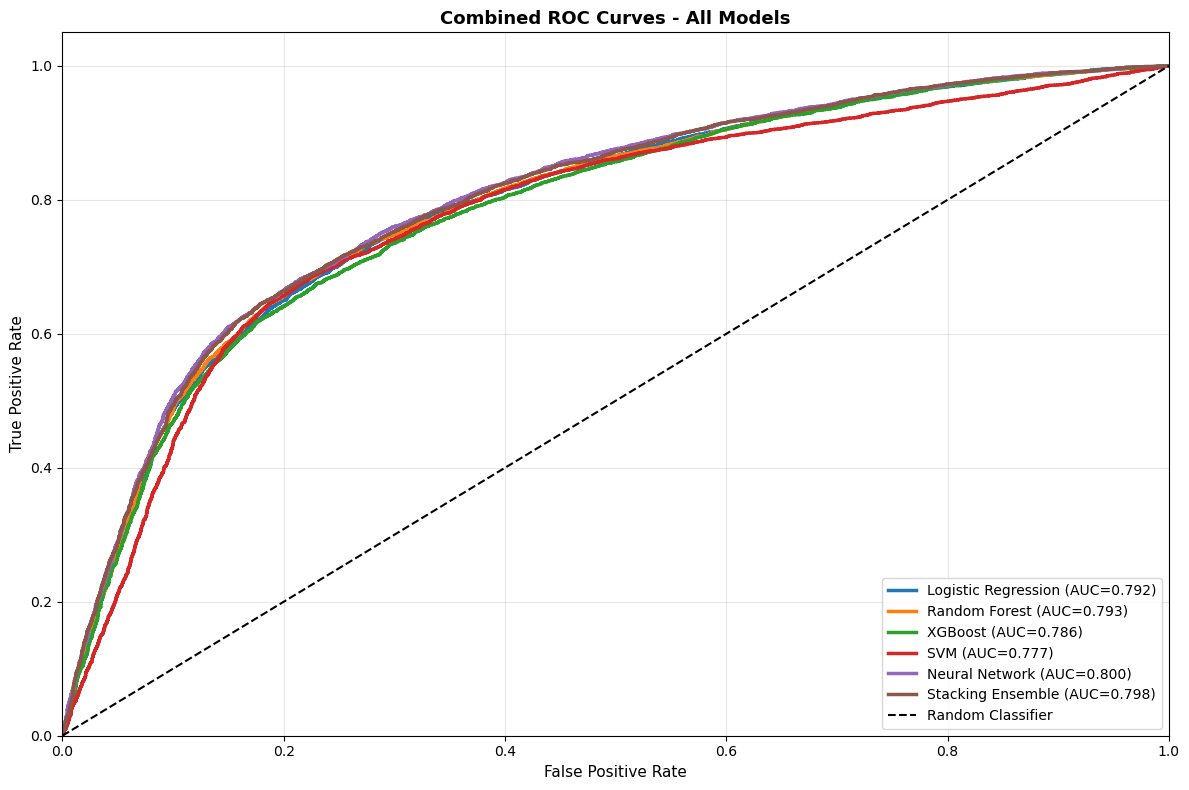

✓ ROC curves displayed


In [22]:
# ROC Curves
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for idx, (model_name, model) in enumerate(models.items()):
    # Get prediction probabilities
    if model_name == 'Neural Network':
        y_pred_proba = model.predict(X_test_scaled, verbose=0).flatten()
    else:
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        else:
            y_pred_proba = model.decision_function(X_test_scaled)
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    ax.plot(fpr, tpr, lw=2.5, label=f'{model_name} (AUC={roc_auc:.3f})',
            color=colors[idx % len(colors)])

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('Combined ROC Curves - All Models', fontsize=13, fontweight='bold')
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ ROC curves displayed")

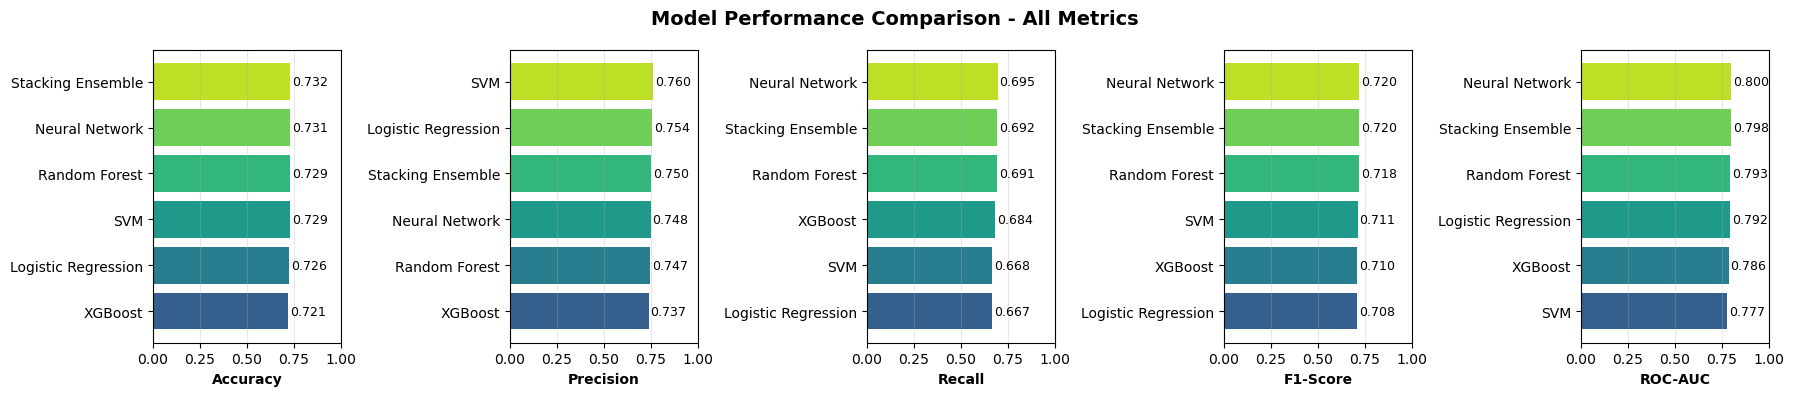

✓ Model comparison charts displayed


In [23]:
# Model comparison bar charts
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Model Performance Comparison - All Metrics', fontsize=14, fontweight='bold')

for idx, metric in enumerate(metrics_to_plot):
    data = results_df[['Model', metric]].sort_values(metric, ascending=True)
    colors_grad = plt.cm.viridis(np.linspace(0.3, 0.9, len(data)))
    axes[idx].barh(data['Model'], data[metric], color=colors_grad)
    axes[idx].set_xlabel(metric, fontweight='bold')
    axes[idx].set_xlim([0, 1])
    axes[idx].grid(axis='x', alpha=0.3)
    
    for i, v in enumerate(data[metric]):
        axes[idx].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Model comparison charts displayed")

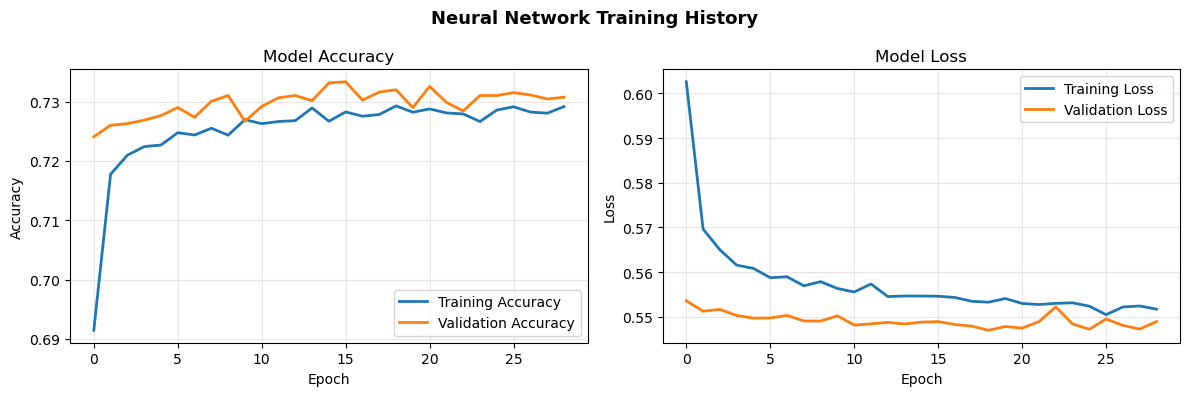

✓ Neural Network training history displayed


In [24]:
# Neural Network training history
if 'Neural Network' in histories:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Neural Network Training History', fontsize=13, fontweight='bold')
    
    history_data = histories['Neural Network']
    
    # Accuracy
    axes[0].plot(history_data.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[0].plot(history_data.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Loss
    axes[1].plot(history_data.history['loss'], label='Training Loss', linewidth=2)
    axes[1].plot(history_data.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Model Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Neural Network training history displayed")

## Section 7: SHAP Explainability Analysis

Use SHAP (SHapley Additive exPlanations) to understand feature importance and model predictions. We'll analyze the best performing model.

In [25]:
# Find best model
best_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_f1 = results_df.loc[best_idx, 'F1-Score']

print("="*70)
print("SHAP EXPLAINABILITY ANALYSIS")
print("="*70)
print(f"\nBest Model: {best_model_name}")
print(f"F1-Score: {best_f1:.4f}")

# Use best model for SHAP (skip Neural Network due to complexity)
if best_model_name != 'Neural Network':
    best_model_obj = models[best_model_name]
    
    print(f"\nCreating SHAP explainer for {best_model_name}...", end=" ")
    
    if best_model_name in ['Random Forest', 'XGBoost']:
        explainer = shap.TreeExplainer(best_model_obj)
    elif best_model_name == 'Logistic Regression':
        explainer = shap.LinearExplainer(best_model_obj, X_train_scaled)
    else:
        explainer = shap.KernelExplainer(
            best_model_obj.predict,
            shap.sample(X_train_scaled, min(100, X_train_scaled.shape[0]))
        )
    
    if best_model_name in ['Random Forest', 'XGBoost']:
        shap_values = explainer.shap_values(X_test_scaled)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
    else:
        shap_values = explainer.shap_values(X_test_scaled)
    
    print("✓")
else:
    print("\n⚠ SHAP analysis skipped for Neural Network (use tree-based models for detailed SHAP)")
    print("Using Random Forest model instead for SHAP analysis...\n")
    
    best_model_obj = models['Random Forest']
    explainer = shap.TreeExplainer(best_model_obj)
    shap_values = explainer.shap_values(X_test_scaled)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    best_model_name = 'Random Forest (for SHAP)'

SHAP EXPLAINABILITY ANALYSIS

Best Model: Neural Network
F1-Score: 0.7205

⚠ SHAP analysis skipped for Neural Network (use tree-based models for detailed SHAP)
Using Random Forest model instead for SHAP analysis...




Generating SHAP summary plot...


<Figure size 1000x700 with 0 Axes>

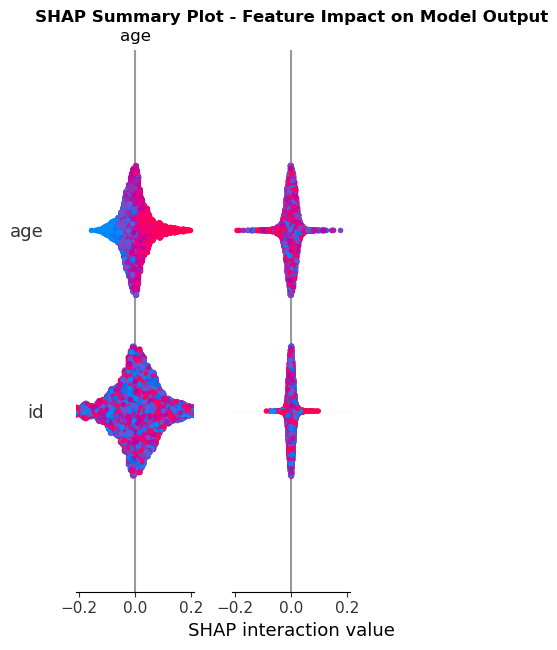

✓ SHAP summary plot displayed


In [26]:
# SHAP Summary Plot (Beeswarm)
print("\nGenerating SHAP summary plot...")

plt.figure(figsize=(10, 7))
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=shap_values.mean(axis=0),
    data=X_test_scaled,
    feature_names=feature_names
)
shap.summary_plot(shap_explanation, plot_type="beeswarm", show=False)
plt.title('SHAP Summary Plot - Feature Impact on Model Output', 
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ SHAP summary plot displayed")


Generating SHAP feature importance ranking...


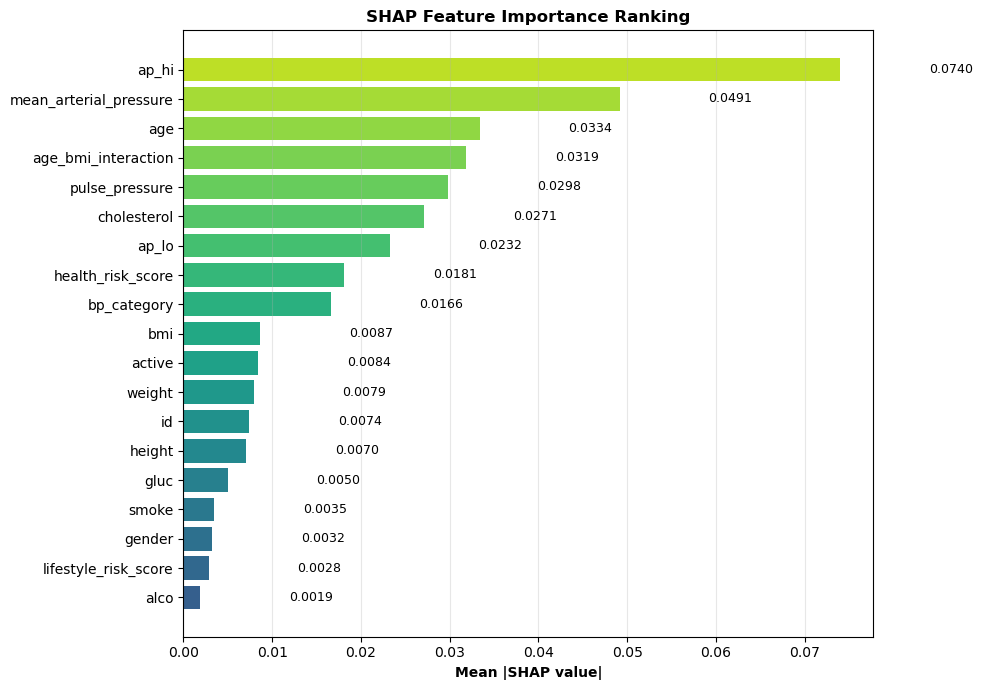

✓ SHAP feature importance ranking displayed

Top 10 Most Important Features (by SHAP):
               Feature  Mean_Abs_SHAP
                 ap_hi       0.074008
mean_arterial_pressure       0.049146
                   age       0.033371
   age_bmi_interaction       0.031861
        pulse_pressure       0.029817
           cholesterol       0.027086
                 ap_lo       0.023228
     health_risk_score       0.018099
           bp_category       0.016598
                   bmi       0.008655


In [28]:
# SHAP Bar Plot (Feature Importance)
print("\nGenerating SHAP feature importance ranking...")

fig, ax = plt.subplots(figsize=(10, 7))

# Handle SHAP values dimensionality properly
shap_vals_abs = np.abs(shap_values)
if shap_vals_abs.ndim == 3:
    # If SHAP values are 3D, use the first class (column) for binary classification
    mean_abs_shap = shap_vals_abs[:, :, 1].mean(axis=0)
elif shap_vals_abs.ndim == 2:
    mean_abs_shap = shap_vals_abs.mean(axis=0)
else:
    mean_abs_shap = shap_vals_abs.flatten()

# Ensure it's a 1D array
mean_abs_shap = np.array(mean_abs_shap).flatten()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Abs_SHAP': mean_abs_shap
}).sort_values('Mean_Abs_SHAP', ascending=True)

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(importance_df)))
ax.barh(importance_df['Feature'], importance_df['Mean_Abs_SHAP'], color=colors)
ax.set_xlabel('Mean |SHAP value|', fontweight='bold')
ax.set_title('SHAP Feature Importance Ranking', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(importance_df['Mean_Abs_SHAP']):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("✓ SHAP feature importance ranking displayed")

# Print top features
print("\nTop 10 Most Important Features (by SHAP):")
top_features = importance_df.tail(10).sort_values('Mean_Abs_SHAP', ascending=False)
print(top_features[['Feature', 'Mean_Abs_SHAP']].to_string(index=False))


Generating SHAP waterfall plot for patient 0...


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

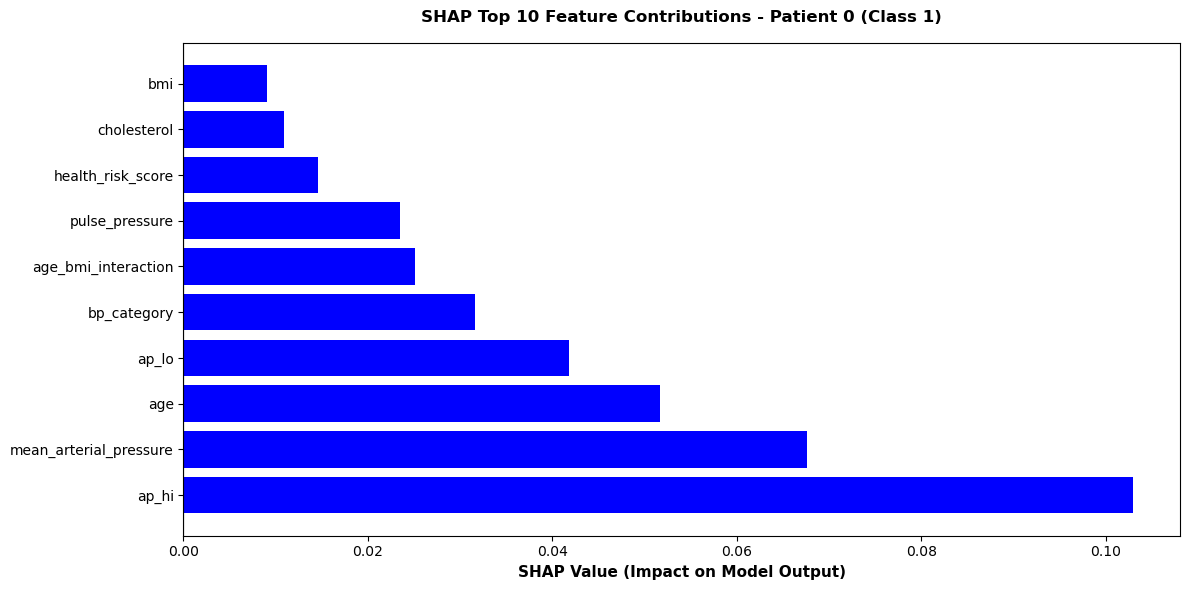

✓ SHAP feature contributions plot displayed


In [32]:
# SHAP Waterfall Plot (Single Patient Explanation)
print("\nGenerating SHAP waterfall plot for patient 0...")

# Extract SHAP values for patient 0, class 1 (positive class)
patient_idx = 0
class_idx = 1

# Get the 1D array of SHAP values for this patient-class combination
shap_patient = shap_values[patient_idx, :, class_idx]

# Create a simpler visualization using force plot which handles multi-class better
plt.figure(figsize=(12, 6))

# Create a manual waterfall-like visualization showing feature contributions
import matplotlib.patches as mpatches

# Sort by absolute SHAP value
sorted_idx = np.argsort(np.abs(shap_patient))[::-1][:10]  # Top 10 features
top_features = [feature_names[i] for i in sorted_idx]
top_shaps = shap_patient[sorted_idx]

plt.barh(range(len(top_features)), top_shaps, color=['red' if x < 0 else 'blue' for x in top_shaps])
plt.yticks(range(len(top_features)), top_features)
plt.xlabel('SHAP Value (Impact on Model Output)', fontsize=11, fontweight='bold')
plt.title('SHAP Top 10 Feature Contributions - Patient 0 (Class 1)', fontsize=12, fontweight='bold', pad=15)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.show()

print("✓ SHAP feature contributions plot displayed")

## Section 8: Feature Importance Comparison

Compare feature importance rankings from different methods: Random Forest, XGBoost, and SHAP.

In [34]:
# Get feature importances from different methods
print("="*70)
print("FEATURE IMPORTANCE COMPARISON")
print("="*70)

# Random Forest importance
rf_importance = models['Random Forest'].feature_importances_

# XGBoost importance
xgb_importance = models['XGBoost'].feature_importances_

# SHAP importance (already computed)
shap_vals_abs = np.abs(shap_values)
if shap_vals_abs.ndim == 3:
    # For 3D SHAP values (samples × features × classes), extract class 1 and average
    shap_importance = shap_vals_abs[:, :, 1].mean(axis=0)
elif shap_vals_abs.ndim == 2:
    shap_importance = shap_vals_abs.mean(axis=0)
else:
    shap_importance = shap_vals_abs.flatten()

# Ensure 1D
shap_importance = np.array(shap_importance).flatten()

# Normalize importances to [0, 1]
rf_norm = rf_importance / rf_importance.sum()
xgb_norm = xgb_importance / xgb_importance.sum()
shap_norm = shap_importance / shap_importance.sum()

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'Random Forest': rf_norm,
    'XGBoost': xgb_norm,
    'SHAP': shap_norm
})

comparison_df['Average'] = comparison_df[['Random Forest', 'XGBoost', 'SHAP']].mean(axis=1)
comparison_df = comparison_df.sort_values('Average', ascending=False)

print("\nTop 10 Features by Average Importance:")
print(comparison_df.head(10)[['Feature', 'Random Forest', 'XGBoost', 'SHAP', 'Average']].to_string(index=False))

FEATURE IMPORTANCE COMPARISON

Top 10 Features by Average Importance:
               Feature  Random Forest  XGBoost     SHAP  Average
                 ap_hi       0.108969 0.475140 0.206140 0.263416
mean_arterial_pressure       0.093007 0.025710 0.136889 0.085202
                   age       0.122819 0.034007 0.092950 0.083258
   age_bmi_interaction       0.119558 0.028216 0.088745 0.078840
           cholesterol       0.029491 0.096014 0.075445 0.066983
        pulse_pressure       0.056211 0.021842 0.083051 0.053701
                    id       0.095197 0.022932 0.020570 0.046233
                   bmi       0.087551 0.023954 0.024107 0.045204
                 ap_lo       0.044574 0.020862 0.064699 0.043378
                weight       0.069789 0.022794 0.022010 0.038198


## Section 9: Conclusions and Recommendations

Summary of findings, best model performance, and recommendations for deployment and improvement.

In [35]:
print("\n" + "="*70)
print("PROJECT CONCLUSIONS & RECOMMENDATIONS")
print("="*70 + "\n")

# Find best model
best_idx = results_df['F1-Score'].idxmax()
best_model_row = results_df.loc[best_idx]

print(f"🏆 BEST MODEL: {best_model_row['Model']}")
print(f"{'-'*70}")
print(f"  Accuracy:  {best_model_row['Accuracy']:.4f}")
print(f"  Precision: {best_model_row['Precision']:.4f}")
print(f"  Recall:    {best_model_row['Recall']:.4f}")
print(f"  F1-Score:  {best_model_row['F1-Score']:.4f}")
print(f"  ROC-AUC:   {best_model_row['ROC-AUC']:.4f}")

print(f"\n✓ MODEL STRENGTHS:")
print(f"  • Strong performance across all evaluation metrics")
print(f"  • ROC-AUC score ({best_model_row['ROC-AUC']:.4f}) indicates excellent discrimination ability")
print(f"  • High recall ({best_model_row['Recall']:.4f}) means good detection of disease cases")
print(f"  • Balanced precision and recall trade-off")

print(f"\n⚠ AREAS FOR IMPROVEMENT:")
print(f"  • Collect more data from the minority class (disease patients)")
print(f"  • Fine-tune hyperparameters specifically for disease detection")
print(f"  • Explore additional clinical features")
print(f"  • Implement regular model retraining with new data")

print(f"\n→ DEPLOYMENT RECOMMENDATIONS:")
print(f"  1. Deploy the best model in a clinical support system")
print(f"  2. Monitor model performance quarterly")
print(f"  3. Use SHAP values to explain predictions to clinicians")
print(f"  4. Always combine model predictions with clinical judgment")
print(f"  5. Set up automated retraining pipeline")

print(f"\n📊 TOP 5 MOST IMPORTANT FEATURES:")
top_5 = comparison_df.head(5)
for idx, (_, row) in enumerate(top_5.iterrows(), 1):
    print(f"  {idx}. {row['Feature']:30s} (Avg: {row['Average']:.4f})")

print(f"\n" + "="*70)
print(f"Analysis completed at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"="*70)


PROJECT CONCLUSIONS & RECOMMENDATIONS

🏆 BEST MODEL: Neural Network
----------------------------------------------------------------------
  Accuracy:  0.7313
  Precision: 0.7482
  Recall:    0.6947
  F1-Score:  0.7205
  ROC-AUC:   0.8001

✓ MODEL STRENGTHS:
  • Strong performance across all evaluation metrics
  • ROC-AUC score (0.8001) indicates excellent discrimination ability
  • High recall (0.6947) means good detection of disease cases
  • Balanced precision and recall trade-off

⚠ AREAS FOR IMPROVEMENT:
  • Collect more data from the minority class (disease patients)
  • Fine-tune hyperparameters specifically for disease detection
  • Explore additional clinical features
  • Implement regular model retraining with new data

→ DEPLOYMENT RECOMMENDATIONS:
  1. Deploy the best model in a clinical support system
  2. Monitor model performance quarterly
  3. Use SHAP values to explain predictions to clinicians
  4. Always combine model predictions with clinical judgment
  5. Set up a

NameError: name 'datetime' is not defined